In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import silhouette_score,silhouette_samples

In [0]:
spotify_user_behavior = spark.table(
    "spotify.spotify_user_behavior"
).toPandas()

In [0]:
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width",180)

In [0]:
CLUSTER_FEATURES_V1 = [
    "daily_listening_minutes", #usage intensity
    "sessions_per_day",        #frequency
    "days_active_last_30",     #consistencyspotify_user_behavior = spark.table(
    "avg_session_minutes",     #depth
    "skip_rate",               #content friction
    "liked_songs_pct",         #positive engagement
    "ads_skipped_pct",         #monetization friction
]

In [0]:
base = spotify_user_behavior[["user_id"] + CLUSTER_FEATURES_V1].copy()
K=4
X9 = base[CLUSTER_FEATURES_V1].copy()
Power= PowerTransformer(
    method="yeo-johnson",
    standardize=True,
)
X9_Power = Power.fit_transform(X9)
X9 = pd.DataFrame(X9_Power, columns = CLUSTER_FEATURES_V1, index = base.index)

gmm9= GaussianMixture (
    n_components= K,
    covariance_type = "full",
    random_state=42,
    n_init=5,
    max_iter = 200
)

In [0]:
labels9 = gmm9.fit_predict(X9)
log_likelihood9 = gmm9.score(X9) * len(X9)
sill_avg_9 = silhouette_score(X9, labels9)
base_iter9 = base.copy()
base_iter9["cluster"] = labels9
print(f"\nIteration 9 results | k={K}")
print("Log Likelihood:", round(log_likelihood9,3))
print("Silhouette :", round(sill_avg_9,3))


Iteration 9 results | k=4
Log Likelihood: 47034.039
Silhouette : 0.114


In [0]:
sizes9 = base_iter9["cluster"].value_counts().sort_index()
means9 = (
    base_iter9.groupby("cluster")[CLUSTER_FEATURES_V1]
    .mean()
    .round(3)
)

In [0]:
profile9 = means9.copy()
profile9.insert(0,"cluster_size",sizes9)
print("\n Cluster Profile (means, original scale) -- Iteration 9 (StandardScalar Labels):")
display(profile9)


 Cluster Profile (means, original scale) -- Iteration 9 (StandardScalar Labels):


cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
25773,65.27342687603547,1.0,21.753816812581487,65.27342687603547,0.288,0.3019945361430282,0.5839138415642019
27544,12.85192890075303,1.0,20.59578049211053,12.85192890075303,0.383,0.2620442369633464,0.506244936813634
20403,77.68456173943838,2.63,21.714096469795834,29.20287803362299,0.305,0.29823237098076677,0.5673281092669187
34280,26.892410243702038,1.0,20.87410338994352,26.892410243702038,0.32,0.2865595189213723,0.5298294260373992


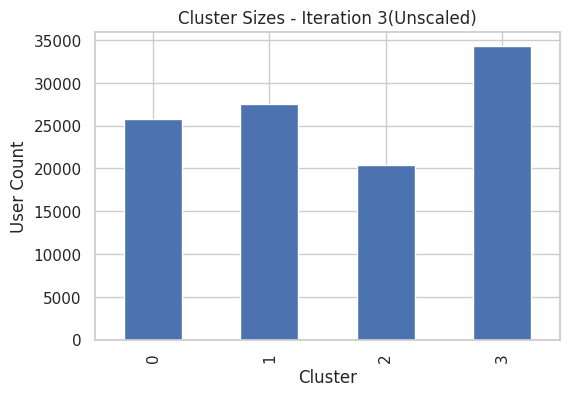

In [0]:
plt.figure(figsize=(6,4))
base_iter9["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Sizes - Iteration 3(Unscaled)")
plt.xlabel("Cluster")
plt.ylabel("User Count")
plt.show()

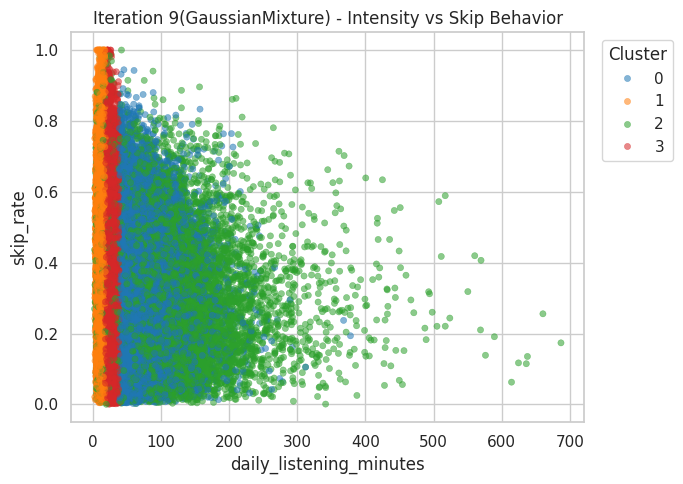

In [0]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data = base_iter9,
    x = "daily_listening_minutes",
    y = "skip_rate",
    hue = "cluster",
    palette = "tab10",
    s= 20,
    alpha = 0.55,
    edgecolor = None
    )
plt.title("Iteration 9(GaussianMixture) - Intensity vs Skip Behavior")
plt.legend(title="Cluster",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()


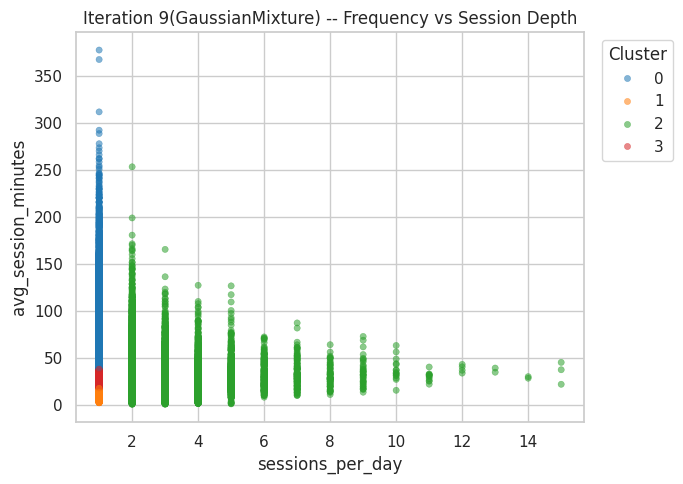

In [0]:
#frequency vs Session depth
plt.figure(figsize=(7,5))
sns.scatterplot(
    data= base_iter9,
    x="sessions_per_day",
    y="avg_session_minutes",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
    edgecolor=None
)
plt.title("Iteration 9(GaussianMixture) -- Frequency vs Session Depth")
plt.legend(title="Cluster",bbox_to_anchor=(1.02, 1),loc="upper left")
plt.tight_layout()
plt.show()

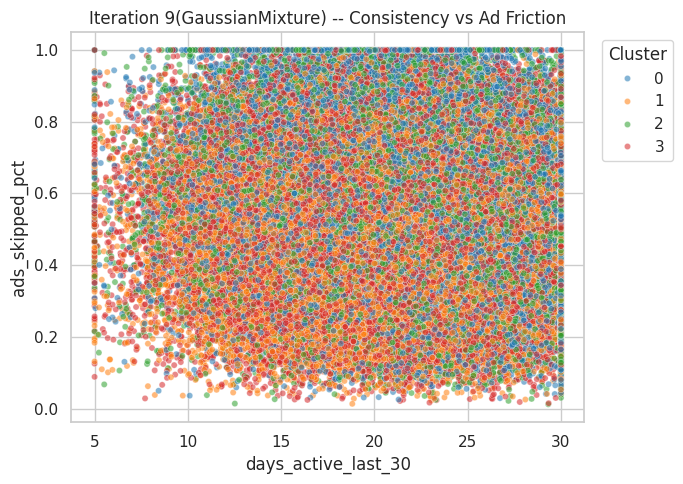

In [0]:
#Consisitency vs Ad Friction
plt.figure(figsize=(7,5))
sns.scatterplot(
    data= base_iter9,
    x="days_active_last_30",
    y="ads_skipped_pct",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.55,
)
plt.title("Iteration 9(GaussianMixture) -- Consistency vs Ad Friction")
plt.legend(title="Cluster",bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

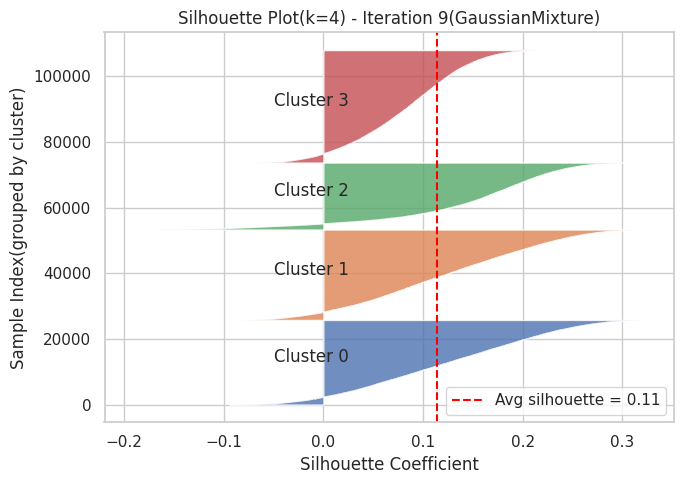

Iteration 9 Avg Silhouette 0.114


In [0]:
# Silhouette Plot
sil_value_9 = silhouette_samples(X9, labels9)
sill_avg_9 = silhouette_score(X9, labels9)
plt.figure(figsize=(7,5))
y_lower = 0

vals0 = sil_value_9[labels9 == 0]
vals0.sort()
size0 = vals0.shape[0]
y_upper = y_lower + size0
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals0,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size0,
    "Cluster 0 "
)
y_lower = y_upper 


vals1 = sil_value_9[labels9 == 1]
vals1.sort()
size1 = vals1.shape[0]
y_upper = y_lower + size1
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size1,
    "Cluster 1 "
)
y_lower = y_upper 


vals2 = sil_value_9[labels9 == 2]
vals2.sort()
size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals2,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size2,
    "Cluster 2 "
)
y_lower = y_upper 


vals3 = sil_value_9[labels9 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals3,
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5*size3,
    "Cluster 3 "
)
y_lower = y_upper 


plt.axvline(
    x=sill_avg_9,
    color="red",
    linestyle="--",
    label = f"Avg silhouette = {sill_avg_9:.2f}"
)
plt.title("Silhouette Plot(k=4) - Iteration 9(GaussianMixture)")
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Sample Index(grouped by cluster)")
plt.legend()
plt.tight_layout()
plt.show()

print("Iteration 9 Avg Silhouette", round(sill_avg_9,3))